In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings

warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "../data/raw/driver_risk.csv"

df = pd.read_csv(
    DATA_PATH,
    sep="\t"
)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (123, 14)


,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0


In [3]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['Weather', 'Road_Type', 'Time_of_Day', 'Traffic_Density', 'Speed_Limit', 'Number_of_Vehicles', 'Driver_Alcohol', 'Accident_Severity', 'Road_Condition', 'Vehicle_Type', 'Driver_Age', 'Driver_Experience', 'Road_Light_Condition', 'Accident']


In [4]:
df = df.dropna(
    how="all"
).reset_index(drop=True)

print("Shape after removing empty rows:", df.shape)

Shape after removing empty rows: (123, 14)


In [5]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

df = df.drop_duplicates().reset_index(drop=True)

print(
    "Shape after removing duplicates:",
    df.shape
)

Duplicate rows: 0
Shape after removing duplicates: (123, 14)


In [6]:
numerical_columns = [
    "Traffic_Density",
    "Speed_Limit",
    "Number_of_Vehicles",
    "Driver_Alcohol",
    "Driver_Age",
    "Driver_Experience",
    "Accident"
]

for col in numerical_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [7]:
print(
    "Missing Accident values:",
    df["Accident"].isna().sum()
)

df = df.dropna(
    subset=["Accident"]
).reset_index(drop=True)

df["Accident"] = df["Accident"].astype(int)

print("\nTarget distribution:")
print(df["Accident"].value_counts())

Missing Accident values: 5

Target distribution:
Accident
0    82
1    36
Name: count, dtype: int64


In [8]:
X = df.drop(
    columns=["Accident"]
)

y = df["Accident"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (118, 13)
y shape: (118,)


In [9]:
if "Accident_Severity" in X.columns:
    X = X.drop(
        columns=["Accident_Severity"]
    )

print("Features used:")
print(X.columns.tolist())

Features used:
['Weather', 'Road_Type', 'Time_of_Day', 'Traffic_Density', 'Speed_Limit', 'Number_of_Vehicles', 'Driver_Alcohol', 'Road_Condition', 'Vehicle_Type', 'Driver_Age', 'Driver_Experience', 'Road_Light_Condition']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (94, 12)
Testing data : (24, 12)


In [12]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Traffic_Density', 'Speed_Limit', 'Number_of_Vehicles', 'Driver_Alcohol', 'Driver_Age', 'Driver_Experience']

Categorical features:
['Weather', 'Road_Type', 'Time_of_Day', 'Road_Condition', 'Vehicle_Type', 'Road_Light_Condition']


In [13]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [14]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [17]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

In [18]:
logistic_params = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "model__solver": [
        "liblinear",
        "lbfgs"
    ]
}

In [19]:
logistic_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_params,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

logistic_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot

In [20]:
print(
    "Best Logistic Regression parameters:"
)

print(
    logistic_search.best_params_
)

print(
    "\nBest CV F1 Score:",
    logistic_search.best_score_
)

Best Logistic Regression parameters:
{'model__C': 10, 'model__solver': 'liblinear'}

Best CV F1 Score: 0.2031257631257631


In [21]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [22]:
random_forest_params = {
    "model__n_estimators": [
        100,
        200,
        300
    ],

    "model__max_depth": [
        None,
        5,
        10,
        15
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__max_features": [
        "sqrt",
        "log2"
    ]
}

In [23]:
random_forest_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=random_forest_params,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_forest_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a bes

In [24]:
random_forest_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=random_forest_params,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_forest_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a bes

In [36]:
print(
    "Best Random Forest parameters:"
)

print(
    random_forest_search.best_params_
)

print(
    "\nBest CV F1 Score:",
    random_forest_search.best_score_
)

Best Random Forest parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10}

Best CV F1 Score: 0.287012987012987


In [37]:
gradient_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

gradient_params = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.7, 0.8, 1.0]
}

In [38]:
gradient_search = RandomizedSearchCV(
    estimator=gradient_pipeline,
    param_distributions=gradient_params,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gradient_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best

In [39]:
print(
    "Best Gradient Boosting parameters:"
)

print(
    gradient_search.best_params_
)

print(
    "\nBest CV F1 Score:",
    gradient_search.best_score_
)

Best Gradient Boosting parameters:
{'model__subsample': 1.0, 'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 2, 'model__learning_rate': 0.1}

Best CV F1 Score: 0.44813852813852817


In [40]:
print(
    "Best Gradient Boosting parameters:"
)

print(
    gradient_search.best_params_
)

print(
    "\nBest CV F1 Score:",
    gradient_search.best_score_
)

Best Gradient Boosting parameters:
{'model__subsample': 1.0, 'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 2, 'model__learning_rate': 0.1}

Best CV F1 Score: 0.44813852813852817


In [41]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_params = {
    "model__n_estimators": [
        100,
        200,
        300
    ],

    "model__learning_rate": [
        0.01,
        0.05,
        0.1,
        0.2
    ],

    "model__max_depth": [
        2,
        3,
        4,
        5,
        6
    ],

    "model__subsample": [
        0.7,
        0.8,
        1.0
    ],

    "model__colsample_bytree": [
        0.7,
        0.8,
        1.0
    ]
}

In [42]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a

In [43]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a

In [44]:
tuned_models = {
    "Logistic Regression": logistic_search,
    "Random Forest": random_forest_search,
    "Gradient Boosting": gradient_search,
    "XGBoost": xgb_search
}

tuned_results = []

for name, search in tuned_models.items():

    tuned_results.append({
        "Model": name,
        "Best CV F1": search.best_score_
    })

tuned_results_df = pd.DataFrame(
    tuned_results
)

tuned_results_df = tuned_results_df.sort_values(
    by="Best CV F1",
    ascending=False
).reset_index(drop=True)

display(tuned_results_df)

,Model,Best CV F1
0,Gradient Boosting,0.448139
1,XGBoost,0.373810
2,Random Forest,0.287013
3,Logistic Regression,0.203126


In [45]:
best_model_name = tuned_results_df.iloc[0]["Model"]

best_search = tuned_models[
    best_model_name
]

final_pipeline = best_search.best_estimator_

print("Best tuned model:")
print(best_model_name)

print("\nBest parameters:")
print(best_search.best_params_)

Best tuned model:
Gradient Boosting

Best parameters:
{'model__subsample': 1.0, 'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 2, 'model__learning_rate': 0.1}


In [46]:
y_pred = final_pipeline.predict(
    X_test
)

y_prob = final_pipeline.predict_proba(
    X_test
)[:, 1]

In [47]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(final_results)

,Metric,Score
0,Accuracy,0.666667
1,Precision,0.428571
2,Recall,0.428571
3,F1 Score,0.428571
4,ROC-AUC,0.798319


In [48]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Accident",
            "Accident"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 No Accident       0.76      0.76      0.76        17
    Accident       0.43      0.43      0.43         7

    accuracy                           0.67        24
   macro avg       0.60      0.60      0.60        24
weighted avg       0.67      0.67      0.67        24



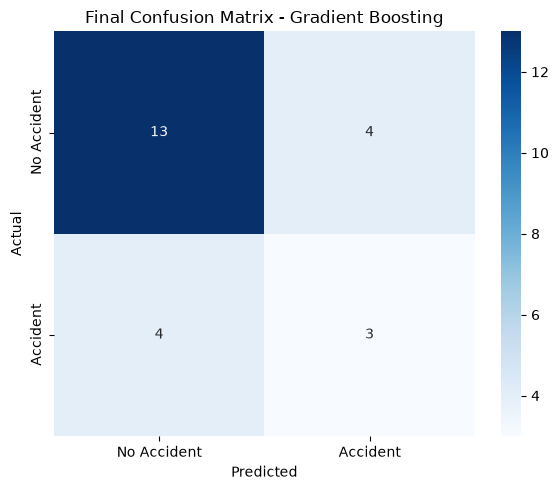

In [49]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Accident",
        "Accident"
    ],
    yticklabels=[
        "No Accident",
        "Accident"
    ]
)

plt.title(
    f"Final Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

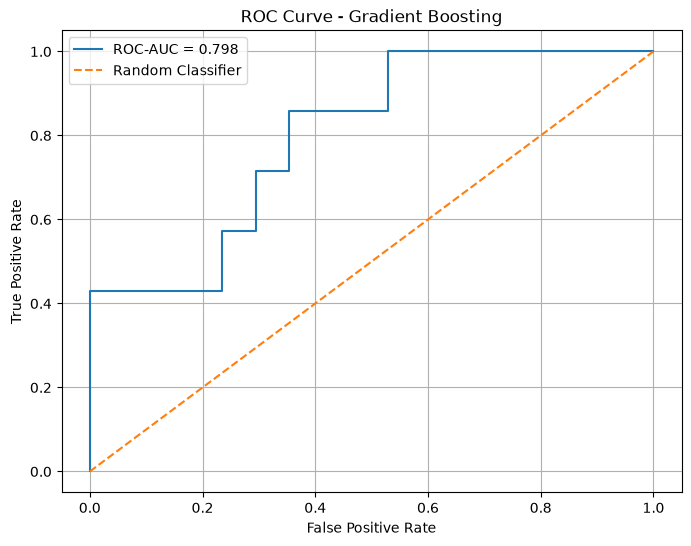

In [50]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"ROC Curve - {best_model_name}"
)

plt.legend()
plt.grid(True)

plt.show()

In [51]:
os.makedirs(
    "../models",
    exist_ok=True
)

FINAL_MODEL_PATH = (
    "../models/final_driver_risk_model.pkl"
)

joblib.dump(
    final_pipeline,
    FINAL_MODEL_PATH
)

print("Final model saved successfully!")
print(FINAL_MODEL_PATH)

Final model saved successfully!
../models/final_driver_risk_model.pkl


In [52]:
final_results.to_csv(
    "../reports/final_model_metrics.csv",
    index=False
)

print(
    "Final metrics saved successfully."
)

Final metrics saved successfully.


In [53]:
best_params_df = pd.DataFrame(
    list(best_search.best_params_.items()),
    columns=[
        "Parameter",
        "Best_Value"
    ]
)

display(best_params_df)

,Parameter,Best_Value
0,model__subsample,1.0
1,model__n_estimators,100.0
2,model__min_samples_split,2.0
3,model__min_samples_leaf,2.0
4,model__max_depth,2.0
5,model__learning_rate,0.1


In [54]:
best_params_df.to_csv(
    "../reports/best_model_parameters.csv",
    index=False
)

In [55]:
print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(f"\nBest Model: {best_model_name}")

print("\nBest Hyperparameters:")
for parameter, value in best_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nFinal Test Metrics:")

for metric, score in zip(
    final_results["Metric"],
    final_results["Score"]
):
    print(f"{metric}: {score:.4f}")

print("\nModel saved at:")
print(FINAL_MODEL_PATH)

FINAL MODEL SUMMARY

Best Model: Gradient Boosting

Best Hyperparameters:
model__subsample: 1.0
model__n_estimators: 100
model__min_samples_split: 2
model__min_samples_leaf: 2
model__max_depth: 2
model__learning_rate: 0.1

Final Test Metrics:
Accuracy: 0.6667
Precision: 0.4286
Recall: 0.4286
F1 Score: 0.4286
ROC-AUC: 0.7983

Model saved at:
../models/final_driver_risk_model.pkl
